# Step 03 — PCA & Clustering

This notebook explores the PCA dimensionality reduction and k-means clustering
results produced by `pipelines/03_cluster.py`.

Two cluster assignments are always produced:
- `cluster`: best k chosen by silhouette score (capped at `k_cap`, default 5)
- `balanced_cluster`: size-constrained k-means at a fixed `balanced_k` (default 5)

Downstream regime labelling uses `balanced_cluster` by default because
equal-size clusters give better per-regime statistics with limited data.

**Run `python pipelines/03_cluster.py` before executing this notebook.**

## Setup & Imports

In [1]:
%matplotlib inline
import sys
sys.path.insert(0, "../src")
import logging
import pandas as pd
import matplotlib.pyplot as plt
from market_regime.config import load, setup_logging
from market_regime.runtime import RunConfig
from market_regime import DATA_DIR, plotting
setup_logging("INFO")
log = logging.getLogger("03_clustering")
cfg = load()
run_cfg = RunConfig(generate_plots=True, save_plots=True, show_plots=False)

In [2]:
import subprocess
from pathlib import Path

def run_step_if_needed(step: int, required_paths: list, auto_run: bool = True) -> bool:
    """Run the pipeline step if any required output files are missing."""
    missing = [p for p in required_paths if not Path(p).exists()]
    if not missing:
        return True
    print(f"Missing: {[str(p) for p in missing]}")
    scripts = sorted(Path("../pipelines").glob(f"{step:02d}_*.py"))
    if not scripts:
        print(f"No pipeline script found for step {step}.")
        return False
    script = scripts[0]
    if not auto_run:
        print(f"  → Run: python {script}")
        return False
    print(f"  → Running {script.name} ...")
    result = subprocess.run(["python", str(script)], capture_output=True, text=True, cwd="..")
    out = result.stdout
    if len(out) > 4000:
        out = out[:2000] + "\n...\n" + out[-2000:]
    print(out)
    if result.returncode != 0:
        print("STDERR:", result.stderr[-1000:])
        return False
    print(f"  ✓ Step {step} complete.")
    return True

# Run clustering step if regime files are missing
run_step_if_needed(3, [
    DATA_DIR / "regimes" / "cluster_labels.parquet",
    DATA_DIR / "regimes" / "pca_components.parquet",
])

True

## Load Clustering Artifacts

Three parquet files are loaded from `data/regimes/`:
- `cluster_labels.parquet` — quarter → cluster assignment (both `cluster` and `balanced_cluster`)
- `pca_components.parquet` — the 5 PCA components for each quarter
- `kmeans_scores.parquet` — silhouette / Calinski-Harabasz / Davies-Bouldin scores for each k

In [3]:
REGIMES_DIR = DATA_DIR / "regimes"

labels = None
pca_df = None
scores = None

try:
    labels = pd.read_parquet(REGIMES_DIR / "cluster_labels.parquet")
    print(f"Labels loaded:         {labels.shape[0]} quarters, columns: {list(labels.columns)}")
except FileNotFoundError:
    print("ERROR: cluster_labels.parquet not found. Run pipelines/03_cluster.py first.")

try:
    pca_df = pd.read_parquet(REGIMES_DIR / "pca_components.parquet")
    print(f"PCA components loaded: {pca_df.shape[0]} quarters x {pca_df.shape[1]} components")
except FileNotFoundError:
    print("ERROR: pca_components.parquet not found. Run pipelines/03_cluster.py first.")

try:
    scores = pd.read_parquet(REGIMES_DIR / "kmeans_scores.parquet")
    print(f"K-sweep scores loaded: {scores.shape[0]} rows, columns: {list(scores.columns)}")
except FileNotFoundError:
    print("ERROR: kmeans_scores.parquet not found. Run pipelines/03_cluster.py first.")

Labels loaded:         304 quarters, columns: ['cluster', 'balanced_cluster', 'market_code']
PCA components loaded: 304 quarters x 5 components
K-sweep scores loaded: 11 rows, columns: ['k', 'inertia', 'silhouette', 'calinski', 'davies_bouldin']


## PCA Explained Variance

The pipeline uses a fixed 5 PCA components (per `n_pca_components` in settings.yaml).
Explained variance is reported if stored separately.

In [4]:
if pca_df is not None:
    print(f"PCA columns: {list(pca_df.columns)}")
    print(f"Shape:       {pca_df.shape}")
    print()
    # Check for separately-stored explained variance
    ev_path = REGIMES_DIR / "pca_explained_variance.parquet"
    try:
        ev = pd.read_parquet(ev_path)
        print("PCA explained variance:")
        display(ev)
    except FileNotFoundError:
        print("(pca_explained_variance.parquet not found — variance not stored separately)")
    print()
    print("First 5 rows of PCA components:")
    display(pca_df.head())

PCA columns: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5']
Shape:       (304, 5)

(pca_explained_variance.parquet not found — variance not stored separately)

First 5 rows of PCA components:


,PC1,PC2,PC3,PC4,PC5
date,,,,,
1950-03-31,2.711780,-1.167017,3.607649,2.798279,1.089949
1950-06-30,2.440854,-1.800320,4.244305,1.684553,0.476226
1950-09-30,1.788419,-2.259959,4.483964,0.224586,-0.257439
1950-12-31,0.576020,-2.470894,4.284812,-2.138648,-1.730186
1951-03-31,-0.650086,-2.033331,3.460589,-4.033916,-2.985986


## K-Sweep Elbow Curves

Three metrics are plotted across the range of k values tested (default k=2..12).
The vertical dashed line marks the automatically chosen best k (max silhouette).

K-sweep scores:


,k,inertia,silhouette,calinski,davies_bouldin
0,2,1307.786151,0.200825,49.005399,2.194470
1,3,1130.648223,0.194964,51.826414,1.768788
2,4,1009.032756,0.200336,50.639312,1.546793
3,5,901.528410,0.189053,51.280415,1.458481
4,6,803.862713,0.190386,53.095860,1.351913
5,7,733.346610,0.187172,53.098143,1.340669
6,8,683.360375,0.185104,51.770494,1.293089
7,9,639.812469,0.184949,50.728794,1.282215
8,10,604.187343,0.179702,49.515348,1.275854
9,11,568.368405,0.184217,49.057628,1.264205



Best k (max silhouette): 2


2026-03-10 15:32:59 | INFO     | market_regime.plotting | Saved plot: /Users/glestryc/personal/github_repos/claude-scratch-work/notebooks/../outputs/plots/03_elbow_curves.png


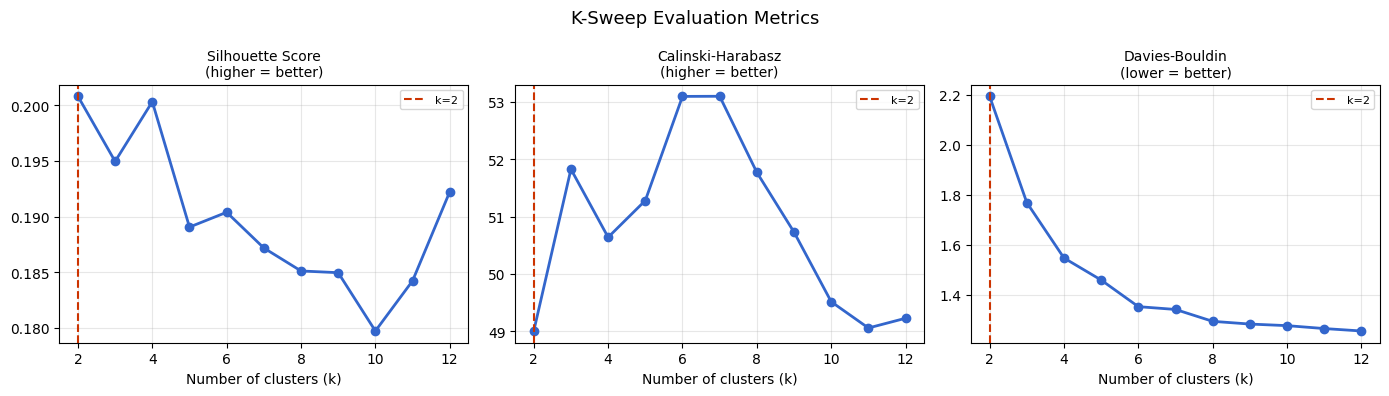

In [5]:
if scores is not None:
    print("K-sweep scores:")
    display(scores)

    if "silhouette" in scores.columns and "k" in scores.columns:
        best_k = int(scores.loc[scores["silhouette"].idxmax(), "k"])
        print(f"\nBest k (max silhouette): {best_k}")
        plotting.plot_elbow_curve(scores, best_k, run_cfg)
    else:
        print(f"Scores DataFrame missing 'silhouette' or 'k' columns.")
        print(f"Available columns: {list(scores.columns)}")

## PCA Scatter Plot

Two scatter panels: PC1 vs PC2, and PC3 vs PC4.
Points are coloured by `balanced_cluster` assignment.
Well-separated clusters in PC space indicate a clean macro regime structure.

2026-03-10 15:32:59 | INFO     | market_regime.plotting | Saved plot: /Users/glestryc/personal/github_repos/claude-scratch-work/notebooks/../outputs/plots/03_pca_scatter.png


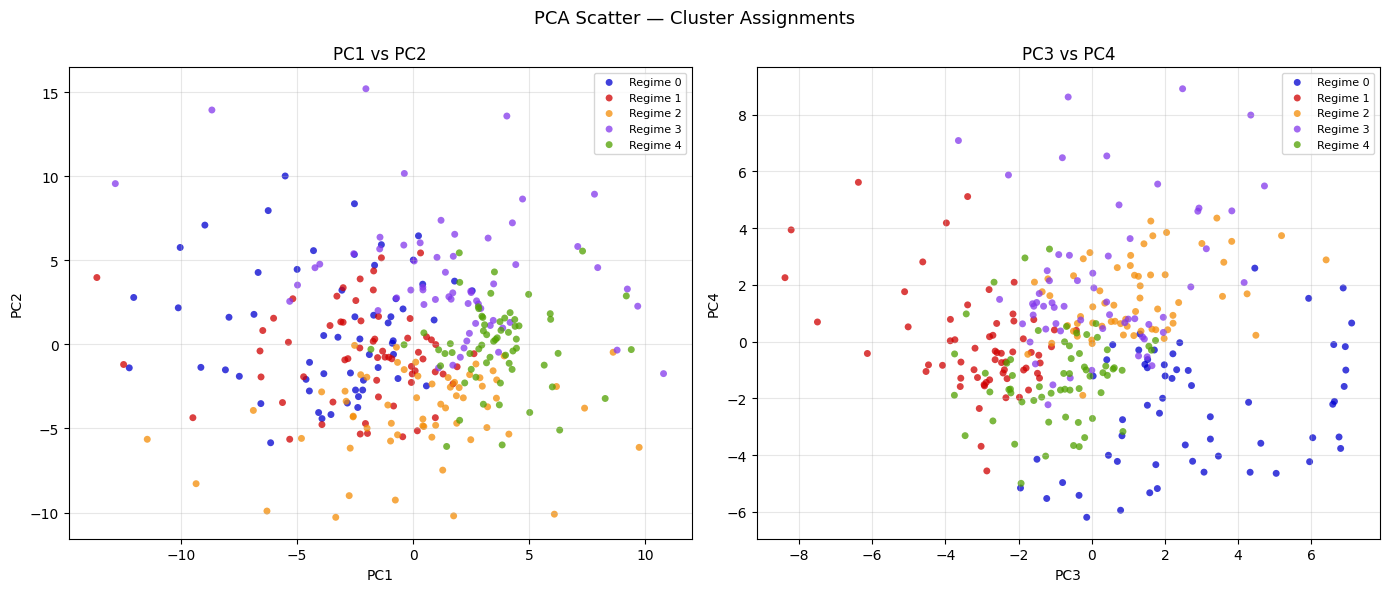

In [6]:
if pca_df is not None and labels is not None:
    if "balanced_cluster" in labels.columns:
        plotting.plot_pca_scatter(pca_df, labels["balanced_cluster"], {}, run_cfg)
    elif "cluster" in labels.columns:
        print("'balanced_cluster' not found — falling back to 'cluster'")
        plotting.plot_pca_scatter(pca_df, labels["cluster"], {}, run_cfg)
    else:
        print(f"No cluster column found. Available columns: {list(labels.columns)}")

## Cluster Sizes

Bar chart showing how many quarters fall into each cluster.
The balanced clustering constrains cluster sizes to be within ±2 of the bucket size.

2026-03-10 15:33:00 | INFO     | market_regime.plotting | Saved plot: /Users/glestryc/personal/github_repos/claude-scratch-work/notebooks/../outputs/plots/03_cluster_sizes.png


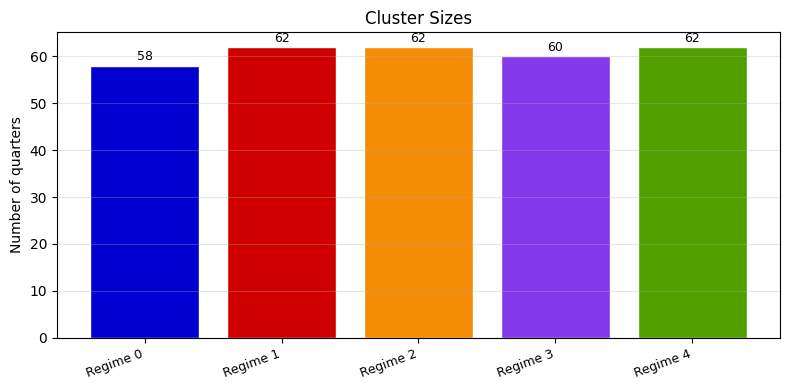

In [7]:
if labels is not None:
    if "balanced_cluster" in labels.columns:
        plotting.plot_cluster_sizes(labels["balanced_cluster"], {}, run_cfg)
    elif "cluster" in labels.columns:
        print("'balanced_cluster' not found — falling back to 'cluster'")
        plotting.plot_cluster_sizes(labels["cluster"], {}, run_cfg)
    else:
        print(f"No cluster column found. Available columns: {list(labels.columns)}")

## Cluster Value Counts

Exact quarter counts for both cluster assignment strategies.

In [8]:
if labels is not None:
    if "cluster" in labels.columns:
        print("=== cluster (silhouette-selected k) ===")
        print(labels["cluster"].value_counts().sort_index().to_string())
        print()

    if "balanced_cluster" in labels.columns:
        print("=== balanced_cluster (size-constrained k) ===")
        print(labels["balanced_cluster"].value_counts().sort_index().to_string())
        print()

    print("=== Sample rows ===")
    display(labels.head(10))

=== cluster (silhouette-selected k) ===
cluster
0    107
1    197

=== balanced_cluster (size-constrained k) ===
balanced_cluster
0    58
1    62
2    62
3    60
4    62

=== Sample rows ===


,cluster,balanced_cluster,market_code
date,,,
1950-03-31,0,2,1.0
1950-06-30,0,2,1.0
1950-09-30,0,2,1.0
1950-12-31,0,0,1.0
1951-03-31,0,0,1.0
1951-06-30,1,0,1.0
1951-09-30,1,0,1.0
1951-12-31,1,4,0.0
1952-03-31,1,1,0.0


## PCA Component Optimization

Sweep `n_components` from 3–10: for each n, fit PCA → KMeans(balanced_k) and record
silhouette, Davies-Bouldin, and cumulative explained variance.  Helps answer whether
**5 components is truly optimal** or whether fewer/more components yield tighter clusters.

The pipeline default (`n_pca_components: 5`) is not changed by this cell — it is a
notebook-only investigation.  If a different n is clearly better, update `settings.yaml`.

In [ ]:
from market_regime.clustering import optimize_n_components

pca_opt_cfg = cfg.get("clustering", {})
n_min = pca_opt_cfg.get("pca_n_range_min", 3)
n_max = pca_opt_cfg.get("pca_n_range_max", 10)
balanced_k = pca_opt_cfg.get("balanced_k", 5)

PROCESSED_DIR = DATA_DIR / "processed"
try:
    features_raw = pd.read_parquet(PROCESSED_DIR / "features.parquet")
    X_clust = features_raw.drop(columns=["market_code"], errors="ignore")
    print(f"Features loaded: {X_clust.shape}")
except FileNotFoundError:
    X_clust = None
    print("ERROR: features.parquet not found. Run pipelines/02_features.py first.")

pca_opt_df = None
if X_clust is not None:
    # Narrow to clustering_features defined in config
    clust_feats = cfg.get("features", {}).get("clustering_features", [])
    available = [c for c in clust_feats if c in X_clust.columns]
    X_for_opt = X_clust[available].dropna()
    print(f"Using {len(available)}/{len(clust_feats)} clustering features, {len(X_for_opt)} quarters")

    pca_opt_df = optimize_n_components(
        X_for_opt,
        n_range=range(n_min, n_max + 1),
        balanced_k=balanced_k,
        random_state=pca_opt_cfg.get("random_state", 42),
    )
    display(pca_opt_df.style.format({
        "explained_variance_pct": "{:.1f}%",
        "silhouette": "{:.4f}",
        "davies_bouldin": "{:.4f}",
        "calinski": "{:.1f}",
    }).background_gradient(subset=["silhouette"], cmap="RdYlGn")
      .background_gradient(subset=["davies_bouldin"], cmap="RdYlGn_r"))

    best_n = int(pca_opt_df.loc[pca_opt_df["silhouette"].idxmax(), "n_components"])
    current_n = pca_opt_cfg.get("n_pca_components", 5)
    print(f"\nBest n by silhouette: {best_n}  (current setting: {current_n})")
    if best_n != current_n:
        print(f"  → Consider updating clustering.n_pca_components: {best_n} in config/settings.yaml")
    else:
        print(f"  ✓ Current setting of {current_n} components is optimal by silhouette.")


In [ ]:
# Plot PCA optimization results
if pca_opt_df is not None:
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    ax = axes[0]
    ax.plot(pca_opt_df["n_components"], pca_opt_df["silhouette"], "o-", color="#0000d0")
    ax.axvline(cfg["clustering"]["n_pca_components"], color="gray", linestyle="--", alpha=0.6, label="current n")
    ax.set_xlabel("n_components"); ax.set_ylabel("Silhouette"); ax.set_title("Silhouette by PCA n"); ax.legend()

    ax = axes[1]
    ax.plot(pca_opt_df["n_components"], pca_opt_df["davies_bouldin"], "o-", color="#d00000")
    ax.axvline(cfg["clustering"]["n_pca_components"], color="gray", linestyle="--", alpha=0.6)
    ax.set_xlabel("n_components"); ax.set_ylabel("Davies-Bouldin (lower=better)"); ax.set_title("Davies-Bouldin by PCA n")

    ax = axes[2]
    ax.plot(pca_opt_df["n_components"], pca_opt_df["explained_variance_pct"], "o-", color="#50a000")
    ax.axvline(cfg["clustering"]["n_pca_components"], color="gray", linestyle="--", alpha=0.6, label="current n")
    ax.set_xlabel("n_components"); ax.set_ylabel("Cumulative Variance (%)"); ax.set_title("PCA Explained Variance")

    fig.suptitle("PCA Component Optimization", fontsize=13)
    fig.tight_layout()
    out = DATA_DIR.parent / "outputs" / "plots" / "03_pca_optimization.png"
    out.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out}")


## SVD vs PCA — Component Comparison

For well-centred data (after StandardScaler), PCA and TruncatedSVD produce nearly
identical components.  This cell shows where they differ and which raw features load
most heavily on each component — useful for interpretability.

In [ ]:
from market_regime.clustering import compare_svd_pca

n_comp = cfg["clustering"]["n_pca_components"]

pca_comp_df = svd_comp_df = loadings_df = None
if X_clust is not None:
    pca_comp_df, svd_comp_df, loadings_df = compare_svd_pca(
        X_for_opt,
        n_components=n_comp,
        random_state=cfg["clustering"]["random_state"],
    )
    print(f"PCA components: {pca_comp_df.shape}")
    print(f"SVD components: {svd_comp_df.shape}")
    print(f"\nTop 5 features loading on PC1 (PCA):")
    print(loadings_df["PCA_PC1"].sort_values(ascending=False).head(5).to_string())
    print(f"\nTop 5 features loading on SV1 (SVD):")
    print(loadings_df["SVD_SV1"].sort_values(ascending=False).head(5).to_string())


In [ ]:
# Plot PCA vs SVD: top-10 feature loadings on first 2 components
if loadings_df is not None:
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    for comp_idx, (pca_col, svd_col) in enumerate(
        [(f"PCA_PC{i+1}", f"SVD_SV{i+1}") for i in range(min(2, n_comp))]
    ):
        for method_idx, col in enumerate([pca_col, svd_col]):
            ax = axes[comp_idx][method_idx]
            top10 = loadings_df[col].sort_values(ascending=False).head(10)
            ax.barh(range(len(top10)), top10.values[::-1], color="#0000d0" if "PCA" in col else "#d00000")
            ax.set_yticks(range(len(top10)))
            ax.set_yticklabels(top10.index[::-1], fontsize=8)
            ax.set_title(f"{col} — Top 10 Feature Loadings")
            ax.set_xlabel("|Loading|")

    fig.suptitle(f"PCA vs SVD: Component Loadings (n={n_comp})", fontsize=13)
    fig.tight_layout()
    out = DATA_DIR.parent / "outputs" / "plots" / "03_svd_vs_pca_loadings.png"
    fig.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out}")


## Multi-Metric k Selection

Four complementary methods for choosing k:
1. **Gap statistic** (Tibshirani 2001) — compares within-cluster dispersion to a uniform reference
2. **BIC via GMM** — likelihood-based model selection (see GMM section below)
3. **Elbow / knee** on inertia — automated via gradient method
4. **Silhouette + CH + DB** — already plotted above

The optimal k from each method often disagrees.  Use judgment to pick the k that
produces the most interpretable and economically meaningful regimes.

In [ ]:
from market_regime.clustering import compute_gap_statistic, find_knee_k
import numpy as np

gap_df = knee_k = None
if scores is not None and pca_df is not None:
    from sklearn.preprocessing import StandardScaler as _SS
    X_scaled = _SS().fit_transform(pca_df.values)

    n_boots = cfg.get("clustering", {}).get("gap_statistic_boots", 10)
    print(f"Computing gap statistic (B={n_boots} bootstraps) ...")
    gap_df = compute_gap_statistic(
        X_scaled,
        k_range=range(2, cfg["clustering"]["n_clusters_search"] + 1),
        n_boots=n_boots,
        random_state=cfg["clustering"]["random_state"],
    )

    optimal_k_gap = int(gap_df.loc[gap_df["optimal"], "k"].iloc[0])
    knee_k = find_knee_k(scores)
    best_sil_k = int(scores.loc[scores["silhouette"].idxmax(), "k"])

    print(f"\nk selection summary:")
    print(f"  Gap statistic optimal k:  {optimal_k_gap}")
    print(f"  Elbow (inertia knee):     {knee_k}")
    print(f"  Silhouette best k:        {best_sil_k}  (capped to {cfg['clustering']['k_cap']} in pipeline)")
    print(f"  Current balanced_k:       {cfg['clustering']['balanced_k']}")
    print()
    display(gap_df.style.format({"gap": "{:.4f}", "gap_std": "{:.4f}", "gap_sk": "{:.4f}"})
            .apply(lambda s: ["background: #90ee90" if v else "" for v in s], subset=["optimal"]))


In [ ]:
# Plot gap statistic alongside silhouette
if gap_df is not None and scores is not None:
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Gap statistic
    ax = axes[0]
    ax.errorbar(gap_df["k"], gap_df["gap"], yerr=gap_df["gap_sk"], fmt="o-", color="#0000d0", capsize=4)
    ax.axvline(int(gap_df.loc[gap_df["optimal"], "k"].iloc[0]), color="green", linestyle="--", label="optimal k")
    ax.axvline(cfg["clustering"]["balanced_k"], color="gray", linestyle=":", label="current balanced_k")
    ax.set_xlabel("k"); ax.set_ylabel("Gap"); ax.set_title("Gap Statistic"); ax.legend(fontsize=8)

    # Silhouette + elbow (knee) marker
    ax = axes[1]
    ax.plot(scores["k"], scores["silhouette"], "o-", color="#8338ec")
    if knee_k:
        ax.axvline(knee_k, color="orange", linestyle="--", label=f"knee k={knee_k}")
    ax.axvline(cfg["clustering"]["balanced_k"], color="gray", linestyle=":", label="current balanced_k")
    ax.set_xlabel("k"); ax.set_ylabel("Silhouette"); ax.set_title("Silhouette Score"); ax.legend(fontsize=8)

    # Inertia elbow
    ax = axes[2]
    ax.plot(scores["k"], scores["inertia"], "o-", color="#f48c06")
    if knee_k:
        ax.axvline(knee_k, color="orange", linestyle="--", label=f"knee k={knee_k}")
    ax.set_xlabel("k"); ax.set_ylabel("Inertia"); ax.set_title("Inertia Elbow"); ax.legend(fontsize=8)

    fig.suptitle("Multi-Metric k Selection", fontsize=13)
    fig.tight_layout()
    out = DATA_DIR.parent / "outputs" / "plots" / "03_k_selection_panel.png"
    fig.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out}")


## Gaussian Mixture Models (GMM)

GMM is a probabilistic alternative to KMeans:
- **Soft assignments**: each quarter has a probability vector over regimes
- **BIC** selects both k and covariance type without manual tuning
- **Elliptical clusters**: models full covariance between PCA components

`diag` covariance recommended for N≈300 (fewer parameters → lower overfit risk).
Compare GMM labels to KMeans labels using adjusted Rand index in the comparison section.

In [ ]:
from market_regime.gmm import fit_gmm, select_gmm_k, gmm_labels, gmm_probabilities

gmm_bic_df = gmm_models = best_gmm_labels = None

if pca_df is not None:
    gmm_cfg = cfg.get("clustering", {}).get("gmm", {})
    cov_types = tuple(gmm_cfg.get("covariance_types", ["diag", "tied", "full"]))
    k_max     = gmm_cfg.get("k_range_max", 10)
    n_init    = gmm_cfg.get("n_init", 10)

    print(f"Fitting GMM: k in [2, {k_max}], cov_types={cov_types}, n_init={n_init} ...")
    gmm_bic_df, gmm_models = fit_gmm(
        pca_df,
        k_range=range(2, k_max + 1),
        covariance_types=cov_types,
        n_init=n_init,
        random_state=cfg["clustering"]["random_state"],
    )

    best_k_gmm, best_cov_gmm = select_gmm_k(gmm_bic_df)
    print(f"\nBest GMM: k={best_k_gmm}, covariance_type='{best_cov_gmm}'")

    best_model = gmm_models[(best_k_gmm, best_cov_gmm)]
    best_gmm_labels = gmm_labels(pca_df, best_model)
    gmm_probs = gmm_probabilities(pca_df, best_model)

    print(f"\nGMM cluster sizes: {best_gmm_labels.value_counts().sort_index().to_dict()}")
    print(f"\nSoft probability sample (first 5 quarters):")
    display(gmm_probs.head())


In [ ]:
# Plot BIC surface: k × covariance_type
if gmm_bic_df is not None:
    import matplotlib.pyplot as plt
    bic_pivot = gmm_bic_df.pivot(index="k", columns="covariance_type", values="bic")
    fig, ax = plt.subplots(figsize=(9, 5))
    for col in bic_pivot.columns:
        ax.plot(bic_pivot.index, bic_pivot[col], "o-", label=col)
    ax.axvline(best_k_gmm, color="gray", linestyle="--", label=f"best k={best_k_gmm} ({best_cov_gmm})")
    ax.set_xlabel("k (number of components)"); ax.set_ylabel("BIC (lower = better)")
    ax.set_title("GMM BIC by k and Covariance Type"); ax.legend()
    fig.tight_layout()
    out = DATA_DIR.parent / "outputs" / "plots" / "03_gmm_bic.png"
    fig.savefig(out, dpi=150, bbox_inches="tight"); plt.show()
    print(f"Saved: {out}")


In [ ]:
# GMM cluster assignments vs KMeans: scatter overlay
if best_gmm_labels is not None and pca_df is not None:
    import matplotlib.pyplot as plt
    from market_regime import plotting

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    pc_cols = [c for c in pca_df.columns if c.startswith("PC")][:2]
    x_lbl, y_lbl = pc_cols[0], pc_cols[1]

    for ax, (lbl_series, title) in zip(axes, [
        (labels["balanced_cluster"] if labels is not None else None, "KMeans (balanced_cluster)"),
        (best_gmm_labels, f"GMM (k={best_k_gmm}, {best_cov_gmm})"),
    ]):
        if lbl_series is None:
            continue
        common = pca_df.index.intersection(lbl_series.index)
        for cid in sorted(lbl_series.loc[common].unique()):
            mask = lbl_series.loc[common] == cid
            ax.scatter(pca_df.loc[common][x_lbl][mask], pca_df.loc[common][y_lbl][mask],
                       c=plotting.CUSTOM_COLORS[cid % 5], label=f"Regime {cid}", s=20, alpha=0.7)
        ax.set_xlabel(x_lbl); ax.set_ylabel(y_lbl); ax.set_title(title); ax.legend(fontsize=7)
    fig.suptitle("KMeans vs GMM Cluster Assignments (PC1 vs PC2)", fontsize=12)
    fig.tight_layout()
    out = DATA_DIR.parent / "outputs" / "plots" / "03_gmm_vs_kmeans.png"
    fig.savefig(out, dpi=150, bbox_inches="tight"); plt.show()
    print(f"Saved: {out}")


## DBSCAN / HDBSCAN — Density-Based Clustering

**Step 1**: plot the k-NN distance curve to choose `eps`.
**Step 2**: sweep `eps` values and inspect cluster counts and noise fraction.
**Step 3**: choose an `eps` that gives a reasonable number of clusters with low noise.

Noise points (label = -1) are quarters that do not fit neatly into any regime —
they may be historically unique or transition periods.

In [ ]:
from market_regime.density import knn_distances, fit_dbscan_sweep, fit_dbscan

dbscan_sweep = best_dbscan_labels = None

if pca_df is not None:
    db_cfg = cfg.get("clustering", {}).get("dbscan", {})
    min_samples = db_cfg.get("min_samples", 5)
    eps_values = db_cfg.get("eps_values", [0.5, 1.0, 1.5, 2.0, 2.5, 3.0])

    # k-NN distance plot
    knn_dists = knn_distances(pca_df, k=min_samples)
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(knn_dists.values, linewidth=1.2)
    ax.set_xlabel("Point rank (sorted)"); ax.set_ylabel(f"Distance to {min_samples}-th neighbour")
    ax.set_title(f"k-NN Distance Plot (k={min_samples}) — find the elbow to set eps")
    ax.grid(alpha=0.3)
    fig.tight_layout()
    out = DATA_DIR.parent / "outputs" / "plots" / "03_dbscan_knn_distance.png"
    fig.savefig(out, dpi=150, bbox_inches="tight"); plt.show()
    print(f"Saved: {out}")

    # Sweep eps
    print(f"\nDBSCAN eps sweep (min_samples={min_samples}) ...")
    dbscan_sweep = fit_dbscan_sweep(pca_df, eps_values=eps_values, min_samples=min_samples)
    display(dbscan_sweep.style.format({"silhouette": "{:.4f}", "noise_pct": "{:.1f}%"})
            .background_gradient(subset=["silhouette"], cmap="RdYlGn"))


In [ ]:
# Fit DBSCAN with chosen eps (pick a value from the sweep above)
if pca_df is not None and dbscan_sweep is not None:
    # Auto-select eps with highest silhouette (non-NaN)
    valid = dbscan_sweep.dropna(subset=["silhouette"])
    if not valid.empty:
        best_eps = float(valid.loc[valid["silhouette"].idxmax(), "eps"])
        print(f"Auto-selected eps={best_eps} (highest silhouette in sweep)")
        print("Override by setting: best_eps = <your chosen value>")
    else:
        best_eps = float(dbscan_sweep["eps"].median())
        print(f"No valid silhouette — using median eps={best_eps}")

    best_dbscan_labels = fit_dbscan(pca_df, eps=best_eps, min_samples=min_samples)
    n_noise = (best_dbscan_labels == -1).sum()
    n_clusters = best_dbscan_labels[best_dbscan_labels >= 0].nunique()
    print(f"\nDBSCAN (eps={best_eps}): {n_clusters} clusters, {n_noise} noise points ({100*n_noise/len(best_dbscan_labels):.1f}%)")
    print(best_dbscan_labels.value_counts().sort_index().to_string())


In [ ]:
# Try HDBSCAN if installed
from market_regime.density import fit_hdbscan_sweep

try:
    if pca_df is not None:
        hdb_cfg = cfg.get("clustering", {}).get("hdbscan", {})
        mcs_list = hdb_cfg.get("min_cluster_sizes", [10, 15, 20, 25])
        print("Running HDBSCAN sweep ...")
        hdbscan_sweep = fit_hdbscan_sweep(pca_df, min_cluster_sizes=mcs_list)
        display(hdbscan_sweep.style.format({"silhouette": "{:.4f}", "noise_pct": "{:.1f}%"})
                .background_gradient(subset=["silhouette"], cmap="RdYlGn"))
except ImportError as e:
    print(f"HDBSCAN not available: {e}")
    print("Install with: pip install hdbscan  or  pip install 'market-regime[clustering-extras]'")
    hdbscan_sweep = None


## Spectral Clustering

Constructs a similarity graph from the PCA components, then clusters its eigenvectors.
Good for non-convex cluster shapes.  Requires specifying k (use optimal k from gap/BIC above).

**Note**: O(N³) eigendecomposition — takes a few seconds at N≈300.

In [ ]:
from market_regime.spectral import fit_spectral_sweep, spectral_labels

spectral_sweep = spectral_all_labels = best_spectral_labels = None

if pca_df is not None:
    spec_cfg = cfg.get("clustering", {}).get("spectral", {})
    affinity   = spec_cfg.get("affinity", "nearest_neighbors")
    n_neighbors = spec_cfg.get("n_neighbors", 10)
    k_max_spec  = spec_cfg.get("k_range_max", 8)

    print(f"Fitting Spectral Clustering: k in [2, {k_max_spec}], affinity={affinity!r} ...")
    spectral_sweep, spectral_all_labels = fit_spectral_sweep(
        pca_df,
        k_range=range(2, k_max_spec + 1),
        affinity=affinity,
        n_neighbors=n_neighbors,
        random_state=cfg["clustering"]["random_state"],
    )
    display(spectral_sweep.style.format({
        "silhouette": "{:.4f}", "davies_bouldin": "{:.4f}", "calinski": "{:.1f}"
    }).background_gradient(subset=["silhouette"], cmap="RdYlGn"))

    if not spectral_sweep.empty:
        best_k_spec = int(spectral_sweep.loc[spectral_sweep["silhouette"].idxmax(), "k"])
        best_spectral_labels = spectral_all_labels.get(best_k_spec)
        print(f"\nBest Spectral k={best_k_spec}")
        if best_spectral_labels is not None:
            print(best_spectral_labels.value_counts().sort_index().to_string())


In [ ]:
# Plot Spectral vs KMeans scatter
if best_spectral_labels is not None and pca_df is not None:
    import matplotlib.pyplot as plt
    from market_regime import plotting
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    pc_cols = [c for c in pca_df.columns if c.startswith("PC")][:2]
    for ax, (lbl_series, title) in zip(axes, [
        (labels["balanced_cluster"] if labels is not None else None, "KMeans (balanced_cluster)"),
        (best_spectral_labels, f"Spectral (k={best_k_spec}, {affinity})"),
    ]):
        if lbl_series is None:
            continue
        common = pca_df.index.intersection(lbl_series.index)
        valid_labels = lbl_series.loc[common][lbl_series.loc[common] >= 0]
        for cid in sorted(valid_labels.unique()):
            mask = valid_labels == cid
            ax.scatter(pca_df.loc[valid_labels.index[mask], pc_cols[0]],
                       pca_df.loc[valid_labels.index[mask], pc_cols[1]],
                       c=plotting.CUSTOM_COLORS[cid % 5], label=f"R{cid}", s=20, alpha=0.7)
        noise_mask = lbl_series.loc[common] == -1
        if noise_mask.any():
            ax.scatter(pca_df.loc[common][pc_cols[0]][noise_mask],
                       pca_df.loc[common][pc_cols[1]][noise_mask],
                       c="lightgray", marker="x", s=15, label="noise")
        ax.set_xlabel(pc_cols[0]); ax.set_ylabel(pc_cols[1]); ax.set_title(title); ax.legend(fontsize=7)
    fig.suptitle("KMeans vs Spectral Clustering (PC1 vs PC2)", fontsize=12)
    fig.tight_layout()
    out = DATA_DIR.parent / "outputs" / "plots" / "03_spectral_vs_kmeans.png"
    fig.savefig(out, dpi=150, bbox_inches="tight"); plt.show()
    print(f"Saved: {out}")


## Multi-Method Comparison

Score all available clustering methods side-by-side and compute pairwise
adjusted Rand index (ARI) between them.  ARI = 1 means identical assignments;
ARI ≈ 0 means no more agreement than chance.

**Selection guidance**: prefer the method with the highest silhouette AND lowest
Davies-Bouldin AND highest ARI agreement with KMeans (stability signal).  If a
method scores much better but has low ARI vs KMeans, inspect it carefully before
adopting as the primary clustering.

In [ ]:
from market_regime.cluster_comparison import compare_all_methods, pairwise_rand_index

# Collect all available clustering labels
all_clustering_labels = {}

if labels is not None and "balanced_cluster" in labels.columns:
    all_clustering_labels["kmeans_balanced"] = labels["balanced_cluster"]
if labels is not None and "cluster" in labels.columns:
    all_clustering_labels["kmeans_silhouette"] = labels["cluster"]
if best_gmm_labels is not None:
    all_clustering_labels[f"gmm_k{best_k_gmm}_{best_cov_gmm}"] = best_gmm_labels
if best_dbscan_labels is not None:
    all_clustering_labels[f"dbscan_eps{best_eps}"] = best_dbscan_labels
if best_spectral_labels is not None:
    all_clustering_labels[f"spectral_k{best_k_spec}"] = best_spectral_labels

print(f"Comparing {len(all_clustering_labels)} clustering methods:")
for name in all_clustering_labels:
    print(f"  {name}")

if pca_df is not None and len(all_clustering_labels) >= 1:
    comparison_df = compare_all_methods(pca_df, all_clustering_labels)
    display(comparison_df.style.format({
        "silhouette": "{:.4f}", "davies_bouldin": "{:.4f}", "calinski": "{:.1f}"
    }).background_gradient(subset=["silhouette"], cmap="RdYlGn")
      .background_gradient(subset=["davies_bouldin"], cmap="RdYlGn_r"))


In [ ]:
# Pairwise Adjusted Rand Index heatmap
if len(all_clustering_labels) >= 2 and pca_df is not None:
    import matplotlib.pyplot as plt
    import numpy as np

    rand_df = pairwise_rand_index(all_clustering_labels)
    fig, ax = plt.subplots(figsize=(max(5, len(rand_df)), max(4, len(rand_df) - 1)))
    im = ax.imshow(rand_df.values, vmin=-0.5, vmax=1, cmap="RdYlGn")
    ax.set_xticks(range(len(rand_df))); ax.set_xticklabels(rand_df.columns, rotation=35, ha="right", fontsize=8)
    ax.set_yticks(range(len(rand_df))); ax.set_yticklabels(rand_df.index, fontsize=8)
    for i in range(len(rand_df)):
        for j in range(len(rand_df)):
            v = rand_df.values[i, j]
            ax.text(j, i, f"{v:.2f}" if np.isfinite(v) else "?", ha="center", va="center", fontsize=8)
    plt.colorbar(im, ax=ax, label="Adjusted Rand Index")
    ax.set_title("Pairwise Adjusted Rand Index — clustering method agreement", fontsize=11)
    fig.tight_layout()
    out = DATA_DIR.parent / "outputs" / "plots" / "03_clustering_rand_heatmap.png"
    fig.savefig(out, dpi=150, bbox_inches="tight"); plt.show()
    print(f"Saved: {out}")


## RF Feature Importance → Clustering Feature Selection

The step-5 RandomForest tells us which features are most predictive of the
current clustering labels.  This gives a data-driven way to evaluate whether
the current `clustering_features` list (69 columns) can be trimmed, and which
features carry the most information.

**Note**: features important for predicting existing labels are not necessarily
the best features for *discovering* new clusters.  Use this as a guide, not
as an automatic replacement for domain judgment.

If you update `clustering_features` in `settings.yaml`, re-run steps 2–5 and
repin regime names in `config/regime_labels.yaml`.

In [ ]:
from market_regime.cluster_comparison import extract_rf_feature_importances, recommend_clustering_features
from market_regime import OUTPUT_DIR

MODELS_DIR = OUTPUT_DIR / "models"
model_path = MODELS_DIR / "current_regime.pkl"

rf_importances = feature_comparison_df = recommended_feats = None
if model_path.exists() and X_clust is not None:
    try:
        rf_importances = extract_rf_feature_importances(model_path)
        print(f"Loaded RF model: {len(rf_importances)} features")

        clust_feats = cfg.get("features", {}).get("clustering_features", [])
        recommended_feats, feature_comparison_df = recommend_clustering_features(
            rf_importances, clust_feats, top_k=35,
        )

        print(f"\nTop-35 features by RF importance (intersection with clustering_features):")
        display(feature_comparison_df.head(40).style.format({"rf_importance": "{:.6f}"})
                .apply(lambda s: ["background: #c8f0c8" if v else "" for v in s], subset=["in_recommended"]))

        print(f"\nFeatures in current clustering_features NOT found in RF model (derivatives):")
        missing = feature_comparison_df[feature_comparison_df["rf_importance"].isna()]["feature"].tolist()
        print(missing)

    except Exception as e:
        print(f"Could not load RF model: {e}")
        print("Run pipelines/05_predict.py first, then re-run this cell.")
else:
    if not model_path.exists():
        print(f"RF model not found at {model_path}")
        print("Run: python pipelines/05_predict.py")


In [ ]:
# Plot top-20 RF feature importances
if rf_importances is not None:
    import matplotlib.pyplot as plt
    clust_feats_set = set(cfg.get("features", {}).get("clustering_features", []))
    top20 = rf_importances.head(20)
    colors = ["#0000d0" if f in clust_feats_set else "#aaaaaa" for f in top20.index]

    fig, ax = plt.subplots(figsize=(9, 7))
    ax.barh(range(len(top20)), top20.values[::-1], color=colors[::-1])
    ax.set_yticks(range(len(top20)))
    ax.set_yticklabels(top20.index[::-1], fontsize=8)
    ax.set_xlabel("RF Feature Importance")
    ax.set_title("Top-20 Features for Current-Regime RF\n(blue = in clustering_features, gray = not)")
    fig.tight_layout()
    out = DATA_DIR.parent / "outputs" / "plots" / "03_rf_feature_importance.png"
    fig.savefig(out, dpi=150, bbox_inches="tight"); plt.show()
    print(f"Saved: {out}")

    if recommended_feats:
        print(f"\nRecommended clustering_features list ({len(recommended_feats)} features):")
        print("# Copy into config/settings.yaml clustering_features section:")
        for f in recommended_feats:
            print(f"  - {f}")


## Summary — Choosing the Best Clustering

Review the comparison table and Rand index heatmap above.  Use this checklist:

1. **Highest silhouette score** — most compact, well-separated clusters
2. **Lowest Davies-Bouldin** — least intra-cluster scatter relative to separation
3. **High ARI vs kmeans_balanced** — stable relative to current baseline
4. **Interpretable regimes** — make economic sense when profiled in notebook 04
5. **Manageable noise** (for DBSCAN) — `< 10%` noise quarters is reasonable

**To adopt a new clustering as the pipeline baseline:**
```bash
# After choosing best method, re-run step 3 with the right settings, then:
python run_pipeline.py --steps 3 --save-market-code
python run_pipeline.py --steps 4,5,6,7 --market-code clustered --plots
```
Then edit `config/regime_labels.yaml` with new regime names.

In [ ]:
# Final comparison summary printout
if 'comparison_df' in dir() and comparison_df is not None:
    print("=" * 65)
    print("CLUSTERING METHOD COMPARISON SUMMARY")
    print("=" * 65)
    for _, row in comparison_df.iterrows():
        sil = row["silhouette"]
        db  = row["davies_bouldin"]
        print(f"  {row['method']:<35}  k={int(row['n_clusters'])}  "
              f"sil={sil:.4f}  DB={db:.4f}  noise={int(row['n_noise'])}")
    print()
    best_method = comparison_df.iloc[0]["method"]
    print(f"  → Highest silhouette: {best_method}")
    if best_method != "kmeans_balanced":
        print(f"  → Consider adopting '{best_method}' if it also makes economic sense in notebook 04.")
    else:
        print(f"  → Current KMeans pipeline is already the best by silhouette.")
else:
    print("Run the cells above to populate the comparison table.")
